# PyJST in Google Colab

This notebook installs PyJST from GitHub, runs its straight-channel and compression-corner demonstration cases, and displays pressure/convergence figures.

> **GPU note:** Select a GPU in **Runtime → Change runtime type** before running this notebook. The default NumPy examples run on the CPU; the final section uses the optional CuPy backend to execute the solver and performance benchmark on the selected CUDA device.

In [25]:
# Install the package and its optional plotting dependency from GitHub.
%pip install -q --upgrade --force-reinstall "git+https://github.com/VishalKandala/PyJST.git" "matplotlib>=3.7" "cupy-cuda12x>=13.0"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.2 which is incompatible.


In [26]:
from dataclasses import replace

from pyjst import (
    CartesianGrid,
    CompressionCornerCase,
    JSTParameters,
    freestream_initial_state,
    solve,
    uniform_supersonic_case,
)
from pathlib import Path
import importlib
import json
import shutil

import pyjst.postprocess as postprocess
import pyjst.performance as performance
importlib.reload(postprocess)
importlib.reload(performance)
from pyjst.postprocess import mach_number, plot_solution, save_solution_figure
from pyjst.performance import benchmark_suite, save_benchmark_figure, write_benchmark_results

import cupy as cp
device = cp.cuda.runtime.getDeviceProperties(cp.cuda.Device().id)["name"].decode()
print(f"CuPy {cp.__version__} on {device}")
output_dir = Path("pyjst-colab-results")
output_dir.mkdir(exist_ok=True)


CuPy 14.0.1 on NVIDIA A100-SXM4-40GB


## Straight channel: uniform Mach-2 flow

This exact-preservation case should have a pressure ratio of one everywhere and a zero residual.

normalized residual: 0.000e+00


PosixPath('/content/pyjst-colab-results/straight-channel.png')

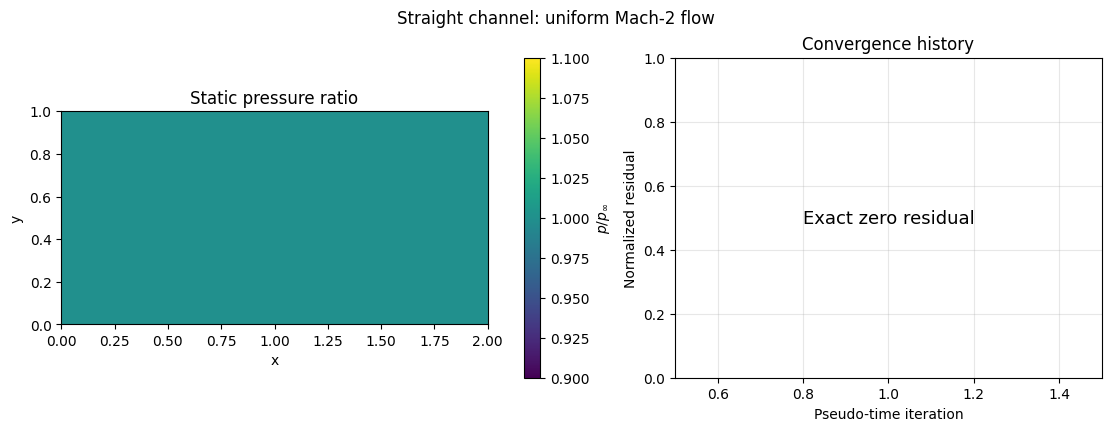

In [27]:
channel_case = replace(uniform_supersonic_case(), numerics=JSTParameters(max_iterations=1))
channel_grid = CartesianGrid(channel_case.grid)
channel_result = solve(freestream_initial_state(channel_grid, channel_case), channel_grid, channel_case)

print(f"normalized residual: {channel_result.residual_history[-1]:.3e}")
plot_solution(channel_result, channel_grid, channel_case, title="Straight channel: uniform Mach-2 flow");
save_solution_figure(channel_result, channel_grid, channel_case, output_dir / "straight-channel.png",
                     title="Straight channel: uniform Mach-2 flow", dpi=300)

## Mach-2, 10-degree compression corner

The body-fitted mesh captures the pressure rise and oblique shock downstream of the corner. The 500-iteration result is a visual demonstration rather than a fully converged validation study.

normalized residual after 500 iterations: 5.475e-01
Mach-number range: 1.580 to 2.073


PosixPath('/content/pyjst-colab-results/cpu-compression-corner.png')

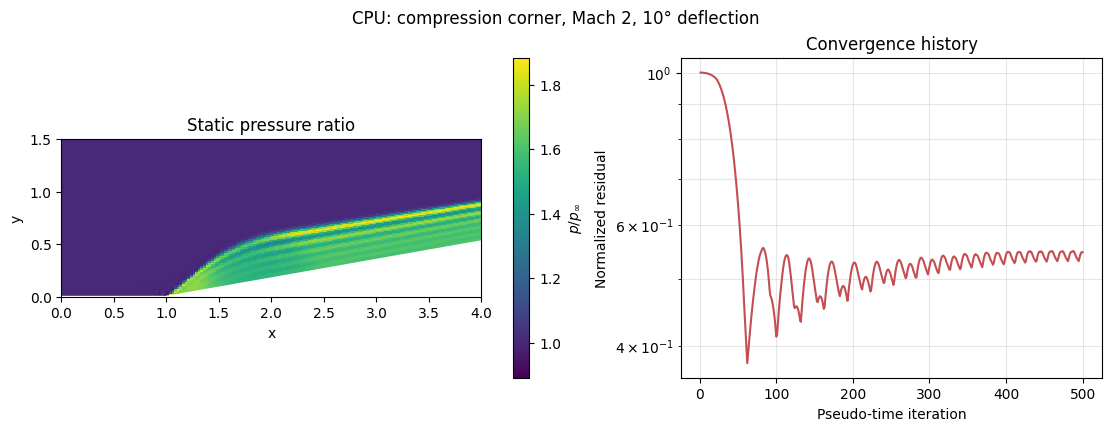

In [28]:
corner_definition = CompressionCornerCase(nx=160, ny=80)
corner_case = replace(
    corner_definition.solver_case(),
    numerics=JSTParameters(cfl=0.4, cfl_initial=0.05, cfl_ramp_iterations=100, max_iterations=500),
)
corner_grid = corner_definition.grid()
corner_result = solve(freestream_initial_state(corner_grid, corner_case), corner_grid, corner_case)

print(f"normalized residual after {corner_result.iterations} iterations: {corner_result.residual_history[-1]:.3e}")
print(f"Mach-number range: {mach_number(corner_result.conservative, corner_grid, corner_case).min():.3f} to {mach_number(corner_result.conservative, corner_grid, corner_case).max():.3f}")
plot_solution(corner_result, corner_grid, corner_case, title="CPU: compression corner, Mach 2, 10° deflection");
save_solution_figure(corner_result, corner_grid, corner_case, output_dir / "cpu-compression-corner.png",
                     title="CPU: compression corner, Mach 2, 10° deflection", dpi=300)

## CuPy GPU solve and CPU/GPU in-situ benchmark

This section requires a Colab GPU runtime. The GPU solve returns its final state to the host only after the pseudo-time march, allowing the existing Matplotlib post-processing to be reused. The final benchmark cell compares NumPy CPU and CuPy GPU execution in one runtime.

PosixPath('/content/pyjst-colab-results/gpu-compression-corner.png')

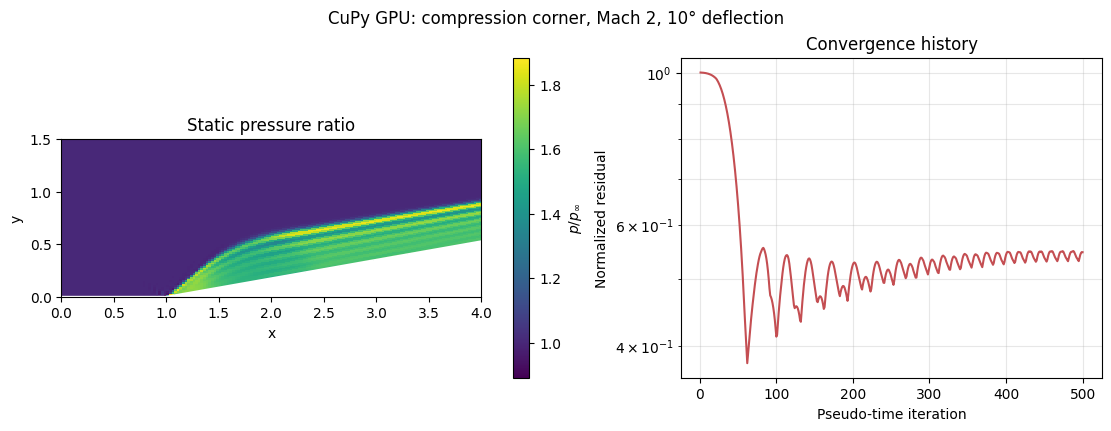

In [29]:
gpu_result = solve(
    freestream_initial_state(corner_grid, corner_case),
    corner_grid,
    corner_case,
    backend="cupy",
)
plot_solution(gpu_result, corner_grid, corner_case, title="CuPy GPU: compression corner, Mach 2, 10° deflection");
save_solution_figure(gpu_result, corner_grid, corner_case, output_dir / "gpu-compression-corner.png",
                     title="CuPy GPU: compression corner, Mach 2, 10° deflection", dpi=300)

## Long CuPy compression-corner run

This run targets a normalized residual of $10^{-6}$ on the 160 × 80 body-fitted grid. It stops immediately on convergence, or at the explicit iteration cap and reports that it did not converge. The exported figure and summary are therefore suitable for documenting either outcome.

In [ ]:
long_run_tolerance = 1.0e-6
long_run_cap = 10_000
long_case = replace(
    corner_definition.solver_case(),
    numerics=JSTParameters(
        cfl=0.4, cfl_initial=0.05, cfl_ramp_iterations=100,
        residual_tolerance=long_run_tolerance, max_iterations=long_run_cap,
    ),
)
long_grid = corner_definition.grid()
long_result = solve(freestream_initial_state(long_grid, long_case), long_grid, long_case, backend="cupy")

status = "converged" if long_result.converged else "iteration cap reached without convergence"
print(f"Long GPU run: {status}")
print(f"iterations: {long_result.iterations:,} / {long_run_cap:,}")
print(f"normalized residual: {long_result.residual_history[-1]:.6e}")
long_figure = output_dir / "gpu-compression-corner-long-run.png"
save_solution_figure(
    long_result, long_grid, long_case, long_figure,
    title=f"CuPy GPU long run: {long_result.iterations:,} iterations, residual {long_result.residual_history[-1]:.2e}",
    dpi=300,
)
(output_dir / "gpu-compression-corner-long-run.json").write_text(json.dumps({
    "grid": [long_case.grid.nx, long_case.grid.ny],
    "iteration_cap": long_run_cap,
    "iterations": long_result.iterations,
    "residual_tolerance": long_run_tolerance,
    "normalized_residual": float(long_result.residual_history[-1]),
    "converged": long_result.converged,
}, indent=2) + "\n")

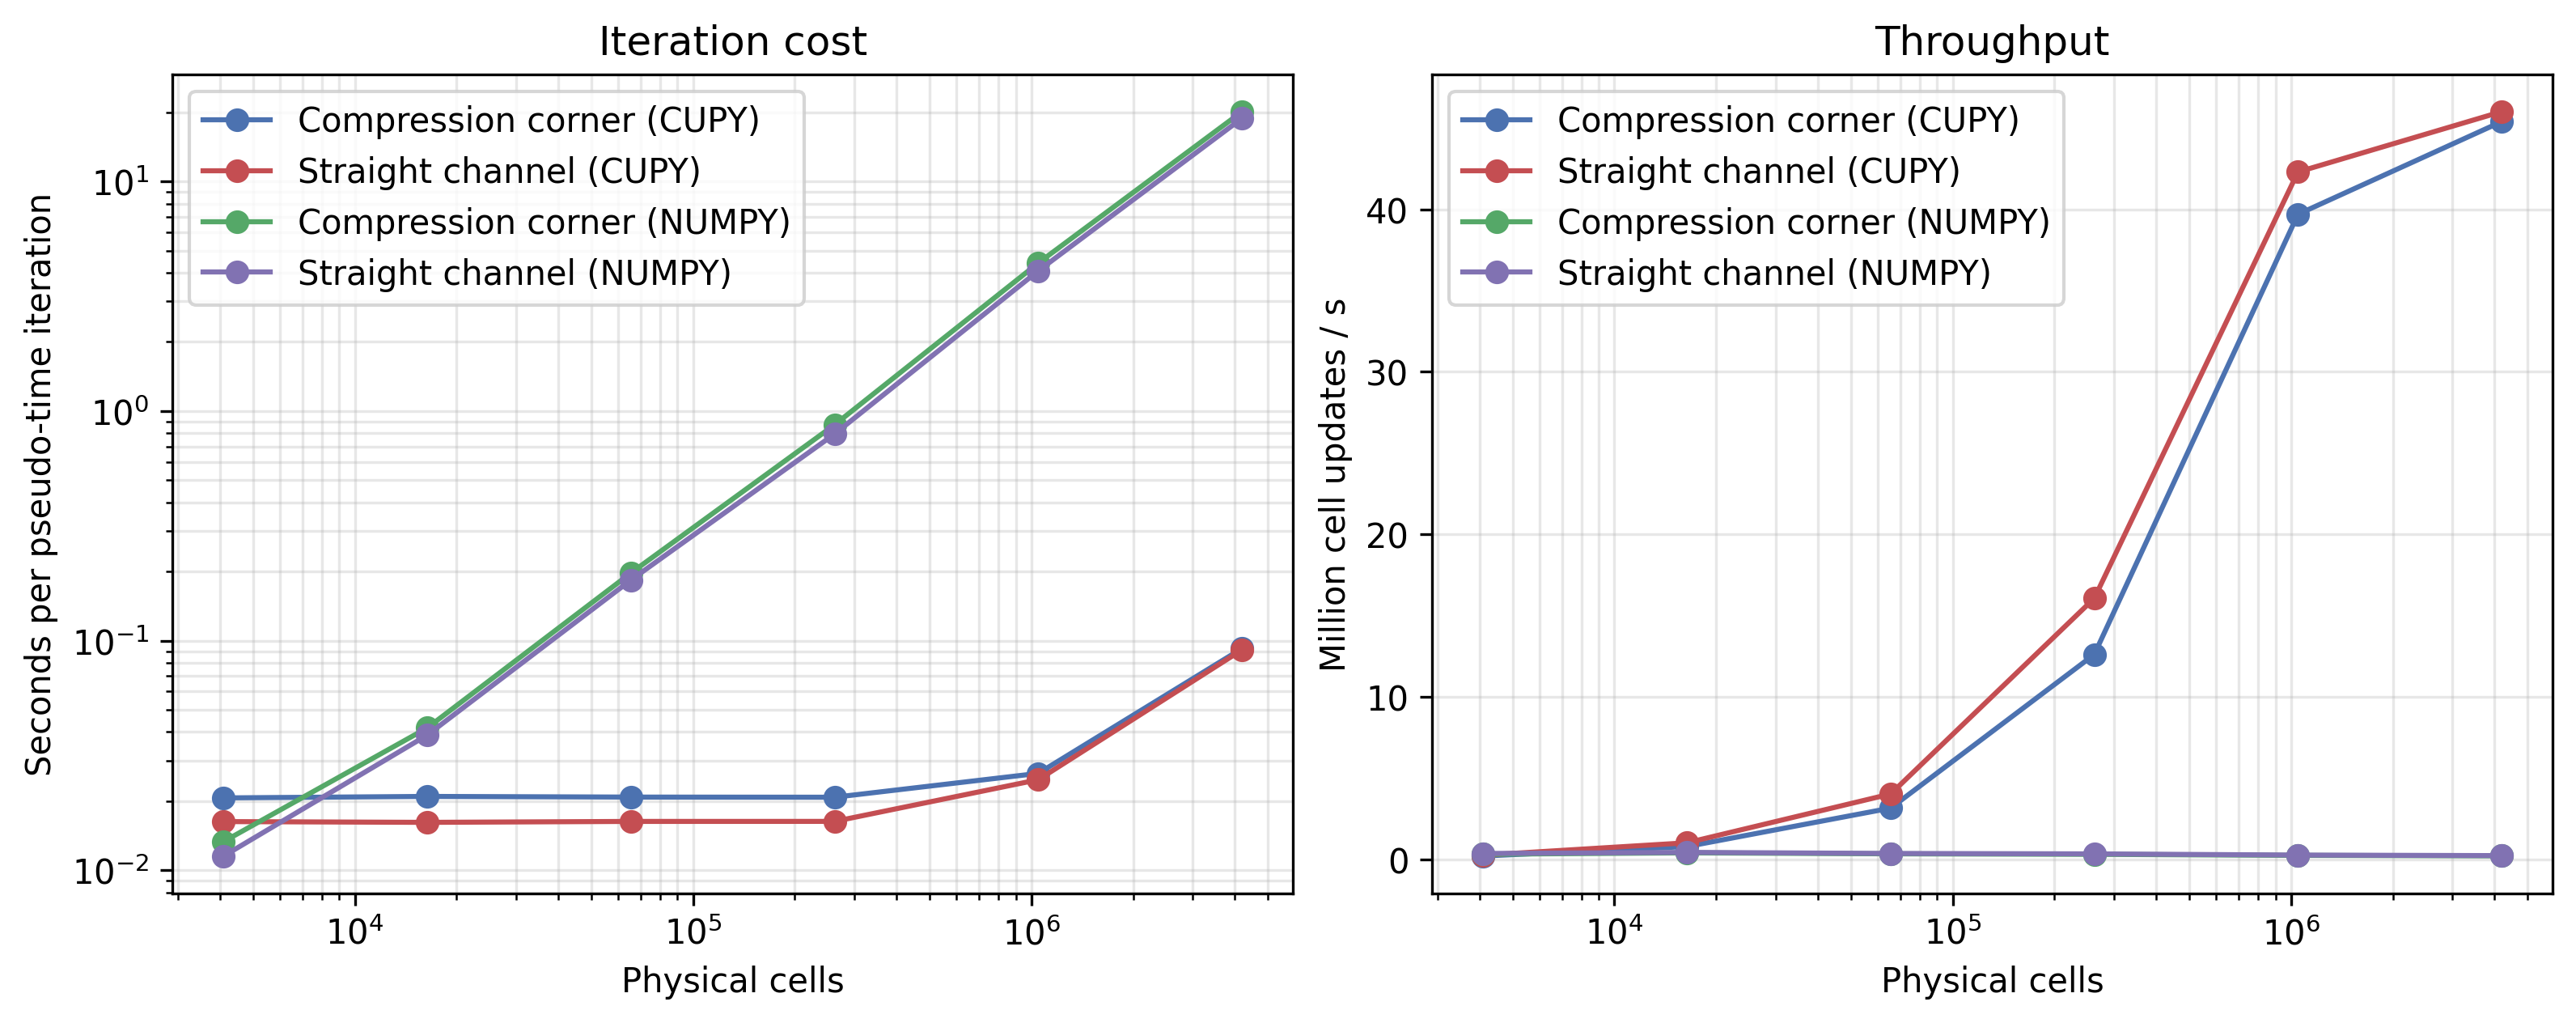

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
# Both backends run in this one GPU-runtime session. CUDA timings synchronize
# the stream and exclude one-time setup and host/device copies.
resolutions = (64, 128, 256, 512, 1024, 2048)
cpu_samples = benchmark_suite(resolutions, repeats=2, warmup_iterations=1, backend="numpy")
gpu_samples = benchmark_suite(resolutions, repeats=3, warmup_iterations=1, backend="cupy")
comparison_samples = cpu_samples + gpu_samples

benchmark_json = output_dir / "cpu-gpu-scaling.json"
benchmark_png = output_dir / "cpu-gpu-scaling.png"
write_benchmark_results(comparison_samples, benchmark_json)
save_benchmark_figure(comparison_samples, benchmark_png, dpi=300)
(output_dir / "run-metadata.json").write_text(json.dumps({
    "gpu": device, "cupy": cp.__version__,
    "cpu_repeats": 2, "gpu_repeats": 3, "warmup_iterations": 1,
}, indent=2) + "\n")

from IPython.display import Image, display
display(Image(filename=str(benchmark_png)))
archive = shutil.make_archive("pyjst-colab-results", "zip", root_dir=output_dir)

try:
    from google.colab import files
    files.download(archive)
except ImportError:
    print(f"Saved shareable artifacts in {output_dir} and {archive}.")